# 02 Preprocessing

od raw MIMIC-III do gotowych zbiorów cech (imputacja, splity 80/20).

Jeśli `processed/chartevents_sample_vitals.csv` i `labevents_sample_cleaned.csv`
już istnieją, ekstrakcja jest pomijana (`FORCE_REEXTRACT = False`).


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()  # THS_Prediction/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config

import os
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

assert config.MIMIC_DIR.exists(), f"MIMIC-III directory not found: {config.MIMIC_DIR}"
print("Environment ready.")
print(f"  MIMIC_DIR:     {config.MIMIC_DIR}")
print(f"  PROCESSED_DIR: {config.PROCESSED_DIR}")


Environment ready.
  MIMIC_DIR:     D:\PyCharmProjects\THS_Prediction\data\MIMIC_III_Clinical
  PROCESSED_DIR: D:\PyCharmProjects\THS_Prediction\processed


## Parametry uruchomienia

In [2]:
# Jeśli None — użyje wartości z config.py
SAMPLE_SIZE_OVERRIDE = None # Maks to 46520

SAMPLE_SIZE = SAMPLE_SIZE_OVERRIDE if SAMPLE_SIZE_OVERRIDE else config.SAMPLE_SIZE

# False = używaj cache
# True  = przetworz od nowa
FORCE_REEXTRACT = True

print(f"SAMPLE_SIZE:     {SAMPLE_SIZE:,} pacjentów")
print(f"FORCE_REEXTRACT: {FORCE_REEXTRACT}")
print(f"RANDOM_SEED:     {config.RANDOM_SEED}")


SAMPLE_SIZE:     46,520 pacjentów
FORCE_REEXTRACT: True
RANDOM_SEED:     42


## Faza 1 — Wczytanie małych tabel MIMIC

In [3]:
def load_mimic(filename):
    p = config.MIMIC_DIR / filename
    if p.exists():       return pd.read_csv(p)
    if (config.MIMIC_DIR / (filename + '.gz')).exists():
        return pd.read_csv(config.MIMIC_DIR / (filename + '.gz'))
    raise FileNotFoundError(f"Cannot find {filename} in {config.MIMIC_DIR}")

patients   = load_mimic('PATIENTS.csv')
admissions = load_mimic('ADMISSIONS.csv')
icustays   = load_mimic('ICUSTAYS.csv')
diagnoses  = load_mimic('DIAGNOSES_ICD.csv')

print(f"PATIENTS:   {len(patients):,} rows")
print(f"ADMISSIONS: {len(admissions):,} rows")
print(f"ICUSTAYS:   {len(icustays):,} rows")
print(f"DIAGNOSES:  {len(diagnoses):,} rows")


PATIENTS:   46,520 rows
ADMISSIONS: 58,976 rows
ICUSTAYS:   61,532 rows
DIAGNOSES:  651,047 rows


## Faza 2 — Przygotowanie admisji (LOS, wiek, filtr dorosłych)

In [4]:
admissions['ADMITTIME'] = pd.to_datetime(admissions['ADMITTIME'])
admissions['DISCHTIME'] = pd.to_datetime(admissions['DISCHTIME'])

# Filtr negatywnego LOS (błędy znaczników czasu)
admissions['LOS_DAYS'] = (admissions['DISCHTIME'] - admissions['ADMITTIME']).dt.total_seconds() / 86400
neg_los = (admissions['LOS_DAYS'] < 0).sum()
admissions = admissions[admissions['LOS_DAYS'] >= 0].copy()
print(f"Removed {neg_los} admissions with negative LOS. Remaining: {len(admissions):,}")

# Wiek przy przyjęciu (per SUBJECT_ID × HADM_ID)
patients['DOB'] = pd.to_datetime(patients['DOB'])
age_df = admissions[['HADM_ID', 'SUBJECT_ID', 'ADMITTIME']].merge(
    patients[['SUBJECT_ID', 'DOB']], on='SUBJECT_ID', how='left'
)
age_df['AGE'] = (age_df['ADMITTIME'].dt.year - age_df['DOB'].dt.year).clip(upper=90)

adult_hadm = set(age_df[age_df['AGE'] >= 18]['HADM_ID'])
total_before = len(admissions)
admissions = admissions[admissions['HADM_ID'].isin(adult_hadm)].copy()

print(f"Adult filter (≥18): removed {total_before - len(admissions):,}, remaining: {len(admissions):,}")
print(f"  Mean age: {age_df.loc[age_df['HADM_ID'].isin(adult_hadm), 'AGE'].mean():.1f}")
del age_df


Removed 98 admissions with negative LOS. Remaining: 58,878
Adult filter (≥18): removed 8,171, remaining: 50,707
  Mean age: 63.9


## Faza 3 — Identyfikacja traumy (ICD-9)

8[0-9][0-9] → kody 800–899: złamania, urazy głowy, klatki, brzucha, kręgosłupa
9[0-5][0-9] → kody 900–959: urazy naczyń, nerwy, powikłania chirurgiczne, inne urazy
E8[0-9]{2} → E800–E899: zewnętrzne przyczyny (wypadki drogowe, upadki, pobicia)
E9[0-2][0-9] → E900–E929: inne zewnętrzne przyczyny (oparzenia, zatrucia, utonięcia)

a SEQ_NUM <= 2 to pierwsze 2 powody hosptializacji

e kody w USA nigdy nie stają na pozycji 1 lekarz zawsze koduje na 1. uraz właściwy (np. 802.0 — złamanie nosa), a E-kod (np. E812 — wypadek samochodowy) dodaje jako kontekst.

In [5]:
trauma_ids_path = config.PROCESSED_DIR / 'trauma_hadm_ids.npy'

# Wczytujemy z dodaniem SEQ_NUM, aby złapać główną przyczynę przyjęcia (SEQ_NUM == 1 lub 2 w niektórych kodowaniach MIMIC)
trauma_mask = diagnoses['ICD9_CODE'].str.match(config.TRAUMA_PATTERN, na=False) & (diagnoses['SEQ_NUM'] <= 3) # == 1 -> 4584
diag_trauma = diagnoses[trauma_mask]

trauma_adm = diag_trauma.merge(
    admissions[['SUBJECT_ID', 'HADM_ID', 'ADMITTIME']], 
    on=['SUBJECT_ID', 'HADM_ID']
)

# Sortujemy po dacie przyjęcia i bierzemy PIERWSZE zdarzenie per pacjent
trauma_first = trauma_adm.sort_values(['SUBJECT_ID', 'ADMITTIME']).drop_duplicates(subset=['SUBJECT_ID'], keep='first') # w pub tego nie zrobili

# Filtr
trauma_hadm = np.array([h for h in trauma_first['HADM_ID'].unique() if h in set(admissions['HADM_ID'])])
trauma_patients = set(trauma_first[trauma_first['HADM_ID'].isin(trauma_hadm)]['SUBJECT_ID'])

np.save(trauma_ids_path, trauma_hadm)
print(f"Trauma patients in MIMIC-III (Total): {len(trauma_patients):,}")
print(f"Trauma admissions (first per patient): {len(trauma_hadm):,}")

Trauma patients in MIMIC-III (Total): 5,176
Trauma admissions (first per patient): 5,176


In [6]:
print("Wykluczanie pacjentów z zabiegami chirurgicznymi...")
procs = pd.read_csv(config.MIMIC_DIR / 'PROCEDURES_ICD.csv.gz')

bedside_exceptions = r'^(389|865|340|311|332|431|387)'

surg_mask = (
    procs['ICD9_CODE'].astype(str).str.match(r'^(0[1-9]|[1-7][0-9]|8[0-6])', na=False) & 
    ~procs['ICD9_CODE'].astype(str).str.match(bedside_exceptions, na=False) &
    (procs['SEQ_NUM'] == 1)
)

surg_hadm = set(procs[surg_mask & procs['HADM_ID'].isin(trauma_hadm)]['HADM_ID'].unique())
trauma_hadm_enrolled = np.array([h for h in trauma_hadm if h not in surg_hadm])

print(f"Exclusions - Patients with surgery treatment: {len(surg_hadm):,}")
print(f"Enrolled patients (Admissions): {len(trauma_hadm_enrolled):,}")

# NADPISUJEMY bazową zmienną trauma_hadm dla Fazy 4
trauma_hadm = trauma_hadm_enrolled

Wykluczanie pacjentów z zabiegami chirurgicznymi...
Exclusions - Patients with surgery treatment: 2,708
Enrolled patients (Admissions): 2,468


## Faza 4 — Losowanie próbki pacjentów

In [7]:
sample_ids_path = config.PROCESSED_DIR / 'sample_subject_ids.npy'

all_subjects  = admissions['SUBJECT_ID'].unique()
n_to_sample   = min(SAMPLE_SIZE, len(all_subjects))

rng = np.random.default_rng(config.RANDOM_SEED)
sample_subject_ids = rng.choice(all_subjects, size=n_to_sample, replace=False)
np.save(sample_ids_path, sample_subject_ids)

sample_subject_set = set(sample_subject_ids)
admissions_sample  = admissions[admissions['SUBJECT_ID'].isin(sample_subject_set)].copy()
sample_hadm_ids    = admissions_sample['HADM_ID'].unique()
trauma_hadm_sample = np.array([h for h in trauma_hadm if h in set(sample_hadm_ids)])

print(f"Sampled {len(sample_subject_ids):,} patients")
print(f"  Admissions in sample: {len(admissions_sample):,}")
print(f"  Trauma admissions:    {len(trauma_hadm_sample):,} ({len(trauma_hadm_sample)/len(admissions_sample)*100:.1f}%)")


Sampled 38,511 patients
  Admissions in sample: 50,707
  Trauma admissions:    2,468 (4.9%)


trauma patients dodac

## Faza 5a — CHARTEVENTS: ekstrakcja sygnałów życiowych


 VS: HR, SBP, DBP, RESP, TEMP) dodatkowo SpO2 jest ekstraktor ale pomijany w vs i MBP dla MAP

In [8]:
# Cache management
vs_save_path = config.PROCESSED_DIR / 'chartevents_sample_vitals.csv'

if FORCE_REEXTRACT and vs_save_path.exists():
    vs_save_path.unlink()
    print("Cache deleted — will re-extract.")

# Flatten vital ITEMIDs
vital_vars = ['HR','SBP','DBP','MBP','RESP','TEMP','SpO2']
vital_itemid_to_name = {i: v for v in vital_vars for i in config.ITEMIDS[v]}
vital_itemids_flat   = list(vital_itemid_to_name.keys())

def extract_chartevents(filepath, hadm_ids, itemids, chunksize=2_000_000):
    hadm_set   = set(hadm_ids)
    itemid_set = set(itemids)
    cols = ['SUBJECT_ID','HADM_ID','ICUSTAY_ID','ITEMID','CHARTTIME','VALUENUM','VALUEUOM']
    chunks_list, total_proc, total_kept = [], 0, 0
    file_mb = filepath.stat().st_size / 1024**2
    est_chunks = int(file_mb / 200)

    print(f"Filtering {len(hadm_set):,} admissions × {len(itemid_set)} ITEMIDs...")
    chunk_iter = pd.read_csv(filepath, usecols=cols, chunksize=chunksize,
                             dtype={'SUBJECT_ID':'Int32','HADM_ID':'Float32','ITEMID':'Int32'})

    with tqdm(total=est_chunks, desc="Processing Chunks") as pbar:
        for chunk in chunk_iter:
            total_proc += len(chunk)
            mask = chunk['HADM_ID'].isin(hadm_set) & chunk['ITEMID'].isin(itemid_set)
            fc = chunk[mask]
            if not fc.empty:
                chunks_list.append(fc)
                total_kept += len(fc)
            pbar.update(1)
            if len(chunks_list) >= 50:
                chunks_list = [pd.concat(chunks_list, ignore_index=True)]
                gc.collect()

    result = pd.concat(chunks_list, ignore_index=True) if chunks_list else pd.DataFrame(columns=cols)
    print(f"Processed: {total_proc:,} | Kept: {total_kept:,} ({total_kept/total_proc*100:.2f}%)")
    return result

if vs_save_path.exists():
    print(f"✓ Cache found — loading from {vs_save_path.name}")
    chartevents_sample = pd.read_csv(vs_save_path)
    chartevents_sample['CHARTTIME'] = pd.to_datetime(chartevents_sample['CHARTTIME'])
    print(f"  Shape: {chartevents_sample.shape}")
else:
    chartevents_path = config.MIMIC_DIR / 'CHARTEVENTS.csv.gz'
    chartevents_sample = extract_chartevents(chartevents_path, sample_hadm_ids, vital_itemids_flat)

    # Map ITEMIDs → variable names
    chartevents_sample['VARIABLE'] = chartevents_sample['ITEMID'].map(vital_itemid_to_name)
    chartevents_sample['CHARTTIME'] = pd.to_datetime(chartevents_sample['CHARTTIME'])
    chartevents_sample = chartevents_sample.dropna(subset=['VALUENUM'])

    # Temperature °F → °C
    temp_mask = chartevents_sample['VARIABLE'] == 'TEMP'
    f_mask    = temp_mask & (chartevents_sample['VALUENUM'] > 45)
    chartevents_sample.loc[f_mask, 'VALUENUM'] = (chartevents_sample.loc[f_mask, 'VALUENUM'] - 32) * 5/9
    print(f"Converted {f_mask.sum():,} temperature records °F→°C")

    # Outlier removal per vital
    initial = len(chartevents_sample)
    for var, (lo, hi) in config.VITAL_RANGES.items():
        var_mask = chartevents_sample['VARIABLE'] == var
        out_mask = (chartevents_sample['VALUENUM'] < lo) | (chartevents_sample['VALUENUM'] > hi)
        n = (var_mask & out_mask).sum()
        if n: chartevents_sample = chartevents_sample[~(var_mask & out_mask)]
    print(f"Outliers removed: {initial - len(chartevents_sample):,}")

    chartevents_sample.to_csv(vs_save_path, index=False)
    print(f"Saved: {vs_save_path} ({vs_save_path.stat().st_size/1024**2:.1f} MB)")

print(f"Final shape: {chartevents_sample.shape}")


Filtering 50,707 admissions × 30 ITEMIDs...


Processing Chunks:   0%|          | 0/20 [00:00<?, ?it/s]

Processed: 330,712,483 | Kept: 37,874,820 (11.45%)
Converted 1,290,802 temperature records °F→°C
Outliers removed: 89,562
Saved: D:\PyCharmProjects\THS_Prediction\processed\chartevents_sample_vitals.csv (2328.1 MB)
Final shape: (37741178, 8)


In [9]:
labs_save_path = config.PROCESSED_DIR / 'labevents_sample_cleaned.csv'

if FORCE_REEXTRACT and labs_save_path.exists():
    labs_save_path.unlink()
    print("Lab cache deleted.")

lab_vars = ['Hemoglobin','Hematocrit','WBC','RBC','Platelets',
            'pH','PaCO2','PaO2','Lactate','Base_Excess','TCO2']
lab_itemid_to_name = {i: v for v in lab_vars for i in config.ITEMIDS[v]}
lab_itemids_flat   = list(lab_itemid_to_name.keys())

def extract_labevents(filepath, hadm_ids, itemids, chunksize=500_000):
    hadm_set   = set(hadm_ids)
    itemid_set = set(itemids)
    cols = ['SUBJECT_ID','HADM_ID','ITEMID','CHARTTIME','VALUENUM']
    chunks_list, total_proc, total_kept = [], 0, 0
    file_mb = filepath.stat().st_size / 1024**2
    est_chunks = int(file_mb / 50)

    chunk_iter = pd.read_csv(filepath, usecols=cols, chunksize=chunksize,
                             dtype={'SUBJECT_ID':'Int32','HADM_ID':'Float32','ITEMID':'Int32'})

    with tqdm(total=est_chunks, desc="Processing Lab Chunks") as pbar:
        for chunk in chunk_iter:
            total_proc += len(chunk)
            mask = chunk['HADM_ID'].isin(hadm_set) & chunk['ITEMID'].isin(itemid_set)
            fc = chunk[mask]
            if not fc.empty:
                chunks_list.append(fc)
                total_kept += len(fc)
            pbar.update(1)
            if len(chunks_list) >= 20:
                chunks_list = [pd.concat(chunks_list, ignore_index=True)]
                gc.collect()

    result = pd.concat(chunks_list, ignore_index=True) if chunks_list else pd.DataFrame(columns=cols)
    print(f"Processed: {total_proc:,} | Kept: {total_kept:,} ({total_kept/total_proc*100:.2f}%)")
    return result

if labs_save_path.exists():
    print(f"✓ Cache found — loading from {labs_save_path.name}")
    labevents_sample = pd.read_csv(labs_save_path)
    labevents_sample['CHARTTIME'] = pd.to_datetime(labevents_sample['CHARTTIME'])
    print(f"  Shape: {labevents_sample.shape}")
else:
    labevents_path = config.MIMIC_DIR / 'LABEVENTS.csv.gz'
    labevents_sample = extract_labevents(labevents_path, sample_hadm_ids, lab_itemids_flat)

    labevents_sample['VARIABLE'] = labevents_sample['ITEMID'].map(lab_itemid_to_name)
    labevents_sample['CHARTTIME'] = pd.to_datetime(labevents_sample['CHARTTIME'])
    labevents_sample = labevents_sample.dropna(subset=['VALUENUM'])

    # Outlier removal
    for test, (lo, hi) in config.LAB_RANGES.items():
        test_mask = labevents_sample['VARIABLE'] == test
        out_mask  = (labevents_sample['VALUENUM'] < lo) | (labevents_sample['VALUENUM'] > hi)
        labevents_sample = labevents_sample[~(test_mask & out_mask)]

    labevents_sample.to_csv(labs_save_path, index=False)
    print(f"Saved: {labs_save_path}")

print(f"Final shape: {labevents_sample.shape}")


Lab cache deleted.


Processing Lab Chunks:   0%|          | 0/6 [00:00<?, ?it/s]

Processed: 27,854,055 | Kept: 5,672,237 (20.36%)
Saved: D:\PyCharmProjects\THS_Prediction\processed\labevents_sample_cleaned.csv
Final shape: (5665505, 6)


## Faza 5b — INPUTEVENTS: transfuzje krwi (Kryterium A)

In [10]:
trans_save_path = config.PROCESSED_DIR / 'inputevents_sample_transfusions.csv'

blood_vars = ['Packed_RBC','Whole_Blood','FFP','Platelet_Transfusion']
blood_itemid_to_name = {i: v for v in blood_vars for i in config.ITEMIDS[v]}
blood_itemids_flat   = list(blood_itemid_to_name.keys())

def extract_inputevents(filepath, hadm_ids, itemids, chunksize=250_000, is_cv=False):
    hadm_set   = set(hadm_ids)
    itemid_set = set(itemids)
    fname = Path(filepath).name
    try:
        peek = pd.read_csv(filepath, nrows=1)
        cols = (['SUBJECT_ID','HADM_ID','ITEMID','CHARTTIME','AMOUNT'] if is_cv
                else ['SUBJECT_ID','HADM_ID','ITEMID','STARTTIME','ENDTIME','AMOUNT'])
        cols = [c for c in cols if c in peek.columns]
        chunks_list, total_proc, total_kept = [], 0, 0
        chunk_iter = pd.read_csv(filepath, usecols=cols, chunksize=chunksize,
                                 dtype={'SUBJECT_ID':'Int32','HADM_ID':'Float32','ITEMID':'Int32'})
        file_mb = Path(filepath).stat().st_size / 1024**2
        with tqdm(total=int(file_mb/25), desc=f"{fname}") as pbar:
            for chunk in chunk_iter:
                total_proc += len(chunk)
                mask = chunk['HADM_ID'].isin(hadm_set) & chunk['ITEMID'].isin(itemid_set)
                fc = chunk[mask]
                if not fc.empty:
                    chunks_list.append(fc)
                    total_kept += len(fc)
                pbar.update(1)
                if len(chunks_list) >= 15:
                    chunks_list = [pd.concat(chunks_list, ignore_index=True)]
                    gc.collect()
        result = pd.concat(chunks_list, ignore_index=True) if chunks_list else pd.DataFrame()
        pct = total_kept/total_proc*100 if total_proc else 0
        print(f"Extracted {total_kept:,} records ({pct:.3f}%)")
        return result
    except Exception as e:
        print(f"Error: {e}")
        return pd.DataFrame()

cv_raw = extract_inputevents(config.MIMIC_DIR/'INPUTEVENTS_CV.csv.gz',
                             sample_hadm_ids, blood_itemids_flat, is_cv=True)
gc.collect()
mv_raw = extract_inputevents(config.MIMIC_DIR/'INPUTEVENTS_MV.csv.gz',
                             sample_hadm_ids, blood_itemids_flat, is_cv=False)
gc.collect()

# Standardize timestamp column name
if not cv_raw.empty and 'CHARTTIME' in cv_raw.columns:
    cv_raw['TRANSFUSION_TIME'] = cv_raw['CHARTTIME']
if not mv_raw.empty and 'STARTTIME' in mv_raw.columns:
    mv_raw['TRANSFUSION_TIME'] = mv_raw['STARTTIME']

common = ['SUBJECT_ID','HADM_ID','ITEMID','TRANSFUSION_TIME','AMOUNT']
cv_c = cv_raw[[c for c in common if c in cv_raw.columns]] if not cv_raw.empty else pd.DataFrame(columns=common)
mv_c = mv_raw[[c for c in common if c in mv_raw.columns]] if not mv_raw.empty else pd.DataFrame(columns=common)

inputevents_sample = pd.concat([cv_c, mv_c], ignore_index=True)
inputevents_sample['PRODUCT'] = inputevents_sample['ITEMID'].map(blood_itemid_to_name)
del cv_raw, mv_raw, cv_c, mv_c; gc.collect()

if not inputevents_sample.empty:
    print("\nTransfusions by product:")
    print(inputevents_sample['PRODUCT'].value_counts().to_string())
    pct = len(inputevents_sample['HADM_ID'].unique()) / len(sample_hadm_ids) * 100
    print(f"Admissions with transfusions: {inputevents_sample['HADM_ID'].nunique():,} ({pct:.2f}%)")
    inputevents_sample.to_csv(trans_save_path, index=False)
    print(f"Saved: {trans_save_path}")


INPUTEVENTS_CV.csv.gz:   0%|          | 0/16 [00:00<?, ?it/s]

Extracted 88,462 records (0.505%)


INPUTEVENTS_MV.csv.gz:   0%|          | 0/5 [00:00<?, ?it/s]

Extracted 14,356 records (0.397%)

Transfusions by product:
PRODUCT
Packed_RBC              56148
FFP                     32374
Platelet_Transfusion    14084
Whole_Blood               212
Admissions with transfusions: 14,433 (28.46%)
Saved: D:\PyCharmProjects\THS_Prediction\processed\inputevents_sample_transfusions.csv


In [11]:
hadm_vitals = set(chartevents_sample['HADM_ID'].unique())
hadm_labs   = set(labevents_sample['HADM_ID'].unique())
hadm_both   = hadm_vitals & hadm_labs

print("DATA COMPLETENESS:")
print(f"  Admissions with Vitals:   {len(hadm_vitals):,} ({len(hadm_vitals)/len(admissions_sample)*100:.1f}%)")
print(f"  Admissions with Labs:     {len(hadm_labs):,} ({len(hadm_labs)/len(admissions_sample)*100:.1f}%)")
print(f"  Admissions with BOTH:     {len(hadm_both):,} ({len(hadm_both)/len(admissions_sample)*100:.1f}%)")
trauma_complete = set(trauma_hadm_sample) & hadm_both
print(f"  Trauma with complete data: {len(trauma_complete):,} / {len(trauma_hadm_sample):,} ({len(trauma_complete)/len(trauma_hadm_sample)*100:.1f}%)")


DATA COMPLETENESS:
  Admissions with Vitals:   48,918 (96.5%)
  Admissions with Labs:     50,103 (98.8%)
  Admissions with BOTH:     48,811 (96.3%)
  Trauma with complete data: 2,417 / 2,468 (97.9%)


## Faza 6 — Pivot do formatu wide, Shock Index, MAP

In [12]:
print("Reshaping vital signs to wide format...")

# 🟢 POPRAWKA: Wyrównanie asynchronicznych pomiarów MIMIC-III.
# Agregujemy czasy do 30-minutowych okien przed pivotowaniem.
chartevents_sample['CHARTTIME_ROUNDED'] = chartevents_sample['CHARTTIME'].dt.floor('30min')

vitals_wide = chartevents_sample.pivot_table(
    index=['SUBJECT_ID','HADM_ID','ICUSTAY_ID','CHARTTIME_ROUNDED'],
    columns='VARIABLE',
    values='VALUENUM',
    aggfunc='median'
).reset_index()

# Przywracamy nazwę kolumny dla zgodności z resztą kodu
vitals_wide = vitals_wide.rename(columns={'CHARTTIME_ROUNDED': 'CHARTTIME'})
vitals_wide.columns.name = None

# 🟢 POPRAWKA: Przeciągamy pomiary o max 2 okna (1h) w przód.
# Pozwoli to połączyć np. SBP zmierzone o 10:00 z HR zmierzonym o 10:30.
vitals_wide = vitals_wide.sort_values(['HADM_ID', 'CHARTTIME'])
cols_to_ffill = ['HR', 'SBP', 'DBP', 'MBP', 'RESP', 'TEMP']
cols_present = [c for c in cols_to_ffill if c in vitals_wide.columns]
vitals_wide[cols_present] = vitals_wide.groupby('HADM_ID')[cols_present].ffill(limit=2)

print(f"Reshaped & FFilled: {vitals_wide.shape}")

# Shock Index = HR / SBP
if 'HR' in vitals_wide.columns and 'SBP' in vitals_wide.columns:
    valid = vitals_wide['SBP'] > 0
    vitals_wide['SI'] = np.nan
    vitals_wide.loc[valid, 'SI'] = vitals_wide.loc[valid,'HR'] / vitals_wide.loc[valid,'SBP']
    vitals_wide.loc[vitals_wide['SI'] > 4, 'SI'] = np.nan  # cap outliers
    
    # Print diagnostyczny
    valid_si_count = vitals_wide['SI'].notna().sum()
    print(f"SI calculated successfully for {valid_si_count:,} rows")
    print(f"SI: mean={vitals_wide['SI'].mean():.3f}, median={vitals_wide['SI'].median():.3f}")

# MAP: measured (MBP) first, calculated fallback
vitals_wide['MAP'] = np.nan
if 'MBP' in vitals_wide.columns:
    vitals_wide['MAP'] = vitals_wide['MBP']
if 'SBP' in vitals_wide.columns and 'DBP' in vitals_wide.columns:
    calc_mask = vitals_wide['MAP'].isna() & vitals_wide['SBP'].notna() & vitals_wide['DBP'].notna()
    vitals_wide.loc[calc_mask, 'MAP'] = (
        vitals_wide.loc[calc_mask,'DBP'] + (vitals_wide.loc[calc_mask,'SBP'] - vitals_wide.loc[calc_mask,'DBP']) / 3
    )
print(f"MAP available: {vitals_wide['MAP'].notna().sum():,} ({vitals_wide['MAP'].notna().mean()*100:.1f}%)")

Reshaping vital signs to wide format...
Reshaped & FFilled: (5429932, 11)
SI calculated successfully for 5,369,370 rows
SI: mean=0.736, median=0.709
MAP available: 5,407,034 (99.6%)


## Faza 7 — Wykrywanie szoku (okno 24h)

In [13]:
# Ogranicz do traumy
trauma_set = set(trauma_hadm_sample)
vitals_trauma = vitals_wide[vitals_wide['HADM_ID'].isin(trauma_set)].copy()

# Merge admission & death time
vitals_trauma = vitals_trauma.merge(
    admissions_sample[['HADM_ID','ADMITTIME', 'DEATHTIME']], on='HADM_ID', how='left'
)
vitals_trauma['ADMITTIME'] = pd.to_datetime(vitals_trauma['ADMITTIME'])
vitals_trauma['DEATHTIME'] = pd.to_datetime(vitals_trauma['DEATHTIME'])
vitals_trauma['HOURS_FROM_ADMIT'] = (
    (vitals_trauma['CHARTTIME'] - vitals_trauma['ADMITTIME']).dt.total_seconds() / 3600
)

vitals_trauma['SHOCK'] = (
    (vitals_trauma['SI']  >= 1.0) &
    (vitals_trauma['MAP'] <= 70)  &
    (vitals_trauma['HOURS_FROM_ADMIT'] >= -24) #>= -24 - > 649
)

# Pierwszy onset szoku per admission (zachowujemy oryginalną logikę publikacji)
shock_onsets = (
    vitals_trauma[vitals_trauma['SHOCK']]
    .groupby('HADM_ID')
    .agg(SHOCK_ONSET_TIME=('CHARTTIME','min'), SUBJECT_ID=('SUBJECT_ID','first'),
         SI=('SI','first'), MAP=('MAP','first'), HR=('HR','first'),
         SBP=('SBP','first'), DBP=('DBP','first'), DEATHTIME=('DEATHTIME', 'first'))
    .reset_index()
)

# WYKLUCZENIE: Śmierć przed szokiem
died_before_shock = shock_onsets[
    (shock_onsets['DEATHTIME'].notna()) & 
    (shock_onsets['DEATHTIME'] <= shock_onsets['SHOCK_ONSET_TIME'])
]['HADM_ID'].unique()

shock_onsets = shock_onsets[~shock_onsets['HADM_ID'].isin(died_before_shock)]
shock_admissions = shock_onsets['HADM_ID'].unique()

print(f"Wykluczono zgonów przed szokiem: {len(died_before_shock)}")
print(f"Trauma admissions with shock (po filtrze zgonów): {len(shock_admissions):,}")

# Zapisz
vitals_trauma.to_csv(config.PROCESSED_DIR / 'vitals_with_shock.csv', index=False)
shock_onsets.to_csv(config.PROCESSED_DIR / 'shock_onsets.csv', index=False)

Wykluczono zgonów przed szokiem: 9
Trauma admissions with shock (po filtrze zgonów): 707


## Faza 8 — Kryteria hemoragii

**A**: transfuzja krwi | **B**: Hb ≤ 9.0 g/dL | **C**: spadek Hb ≥20%

In [14]:
# Kryterium A: Transfuzja krwi 
print("Evaluating Criterion A: Acute Blood Transfusion (PRBC/WB within 12h)...")
transfusions = pd.read_csv(config.PROCESSED_DIR / 'inputevents_sample_transfusions.csv')

# Dołączamy czas przyjęcia, aby obliczyć okno czasowe
transfusions = transfusions.merge(admissions_sample[['HADM_ID', 'ADMITTIME']], on='HADM_ID', how='left')
transfusions['TRANSFUSION_TIME'] = pd.to_datetime(transfusions['TRANSFUSION_TIME'])
transfusions['ADMITTIME'] = pd.to_datetime(transfusions['ADMITTIME'])
transfusions['HOURS_FROM_ADMIT'] = (transfusions['TRANSFUSION_TIME'] - transfusions['ADMITTIME']).dt.total_seconds() / 3600

# 🟢 POPRAWKA: Tylko czerwone krwinki (Packed RBC / Whole Blood) 
# podane w ostrej fazie wstrząsu (od SOR do 12h po przyjęciu na OIT)
red_blood_only = ['Packed_RBC', 'Whole_Blood']
valid_transfusions = transfusions[
    (transfusions['PRODUCT'].isin(red_blood_only)) & 
    (transfusions['HOURS_FROM_ADMIT'].between(-24, 12))
]

criterion_a_hadm = set(valid_transfusions['HADM_ID'].unique())
print(f"Criterion A (Acute PRBC/WB Transfusion): {len(criterion_a_hadm):,}")

Evaluating Criterion A: Acute Blood Transfusion (PRBC/WB within 12h)...
Criterion A (Acute PRBC/WB Transfusion): 2,907


In [15]:
# Kryterium B: Hb <= 9.0 g/dL w ciągu 24h od przyjęcia
hb_events = labevents_sample[labevents_sample['VARIABLE'] == 'Hemoglobin'].copy()
hb_events = hb_events.merge(admissions_sample[['HADM_ID','ADMITTIME']], on='HADM_ID', how='left')
hb_events['ADMITTIME'] = pd.to_datetime(hb_events['ADMITTIME'])
hb_events['HOURS_FROM_ADMIT'] = (hb_events['CHARTTIME'] - hb_events['ADMITTIME']).dt.total_seconds() / 3600

hb_24h = hb_events[hb_events['HOURS_FROM_ADMIT'].between(-6, 24)]
low_hb  = hb_24h[hb_24h['VALUENUM'] <= 9.0]['HADM_ID'].unique()

# SZERSZE WYKLUCZENIA PRZEWLEKŁEJ ANEMII (wg publikacji)
# 140-208: Nowotwory złośliwe
# 200-289: Choroby hematologiczne
# 585.x, 586: CKD
# 571.x, 572.x: Przewlekła choroba wątroby
regex_chronic = r'^(1[4-9][0-9]|20[0-8]|2[0-8][0-9]|58[56]|57[12])'

#chronic_anemia_mask = diagnoses['ICD9_CODE'].astype(str).str.match(regex_chronic, na=False)
chronic_anemia_mask = diagnoses['ICD9_CODE'].astype(str).str.match(config.CHRONIC_DISEASE_PATTERN, na=False)
chronic_anemia_hadm = set(diagnoses[chronic_anemia_mask]['HADM_ID'].unique())

criterion_b_hadm = set(low_hb) - chronic_anemia_hadm
print(f"Criterion B (Low Hb <= 9.0): {len(criterion_b_hadm):,} (after expanded chronic disease exclusions)")

Criterion B (Low Hb <= 9.0): 3,981 (after expanded chronic disease exclusions)


In [16]:
# Kryterium C: spadek Hb ≥ 20% w ciągu 48h
print("Calculating Hemoglobin drop (48h window, baseline from ER to 6h)...")

hb_all = labevents_sample[labevents_sample['VARIABLE'] == 'Hemoglobin'].copy()
hb_all = hb_all.merge(admissions_sample[['HADM_ID','ADMITTIME']], on='HADM_ID', how='left')
hb_all['ADMITTIME'] = pd.to_datetime(hb_all['ADMITTIME'])
hb_all['HOURS'] = (hb_all['CHARTTIME'] - hb_all['ADMITTIME']).dt.total_seconds() / 3600

# 🟢 POPRAWKA: Prawdziwy baseline to PIERWSZE badanie (często wczesne ER, HOURS < 0)
baseline_hb = (
    hb_all[hb_all['HOURS'].between(-6, 6)]
    .sort_values(['HADM_ID', 'CHARTTIME'])
    .groupby('HADM_ID')['VALUENUM'].first()
    .rename('HB_BASELINE')
)

# Minimum w ciągu pełnych 48h
min_hb = (
    hb_all[hb_all['HOURS'].between(-6, 72)] # , 96
    .groupby('HADM_ID')['VALUENUM'].min()
    .rename('HB_MIN')
)

hb_drop_df = pd.concat([baseline_hb, min_hb], axis=1).dropna()
hb_drop_df = hb_drop_df[hb_drop_df['HB_BASELINE'] > 0]
hb_drop_df['DROP_PCT'] = (hb_drop_df['HB_BASELINE'] - hb_drop_df['HB_MIN']) / hb_drop_df['HB_BASELINE'] * 100

criterion_c_hadm = set(hb_drop_df[hb_drop_df['DROP_PCT'] >= 20].index)
print(f"Criterion C (Hb Drop ≥20%): {len(criterion_c_hadm):,}")
del hb_all, hb_drop_df; gc.collect()

Calculating Hemoglobin drop (48h window, baseline from ER to 6h)...
Criterion C (Hb Drop ≥20%): 15,047


19

In [17]:
# Wykluczenie nietraumatycznych przypadków szoku z kohort szoku
non_trauma_shock_codes = (
    config.EXCLUSION_ICD9['septic_shock'] +
    config.EXCLUSION_ICD9['cardiogenic_shock'] +
    config.EXCLUSION_ICD9['anaphylactic_shock']
)

# 1. NAJPIERW definiujemy grupę ze wstrząsem, w której szukamy wykluczeń
shock_hadm_all = set(shock_admissions)

# 2. POTEM filtrujemy diagnozy, optymalizując wyszukiwanie tylko do tej grupy
excl_hadm = set(diagnoses[
    diagnoses['ICD9_CODE'].isin(non_trauma_shock_codes) &
    diagnoses['HADM_ID'].isin(shock_hadm_all)
]['HADM_ID'])

# 3. NA KONIEC odejmujemy wykluczonych od całości wstrząsów
shock_hadm = shock_hadm_all - excl_hadm

print(f"Shock admissions before exclusion: {len(shock_hadm_all):,}")
print(f"Excluded (septic/cardiogenic/anaphylactic): {len(shock_hadm_all & excl_hadm):,}") # Wypisze dokładną liczbę odrzuconych
print(f"Final True Shock Cohort: {len(shock_hadm):,}")

Shock admissions before exclusion: 707
Excluded (septic/cardiogenic/anaphylactic): 28
Final True Shock Cohort: 679


## Faza 9 — Kohorta THS (szok + hemoragia)

In [18]:
hemorrhage_hadm = criterion_a_hadm | criterion_b_hadm | criterion_c_hadm
ths_hadm        = shock_hadm & hemorrhage_hadm

shock_not_ths_hadm = shock_hadm - ths_hadm 

died_at_discharge = set(admissions_sample[admissions_sample['DEATHTIME'].notna()]['HADM_ID'])
non_ths_hadm_full = set(trauma_hadm_sample) - set(shock_hadm_all) - died_at_discharge

RATIO = None   # None = pełna pula; liczba = undersampling (np. 2 = 2×THS)

if RATIO is not None:
    target_non_ths_size = len(ths_hadm) * RATIO
    non_ths_hadm_lst = list(non_ths_hadm_full)
    rng = np.random.default_rng(config.RANDOM_SEED)
    if len(non_ths_hadm_lst) > target_non_ths_size:
        non_ths_hadm_lst = rng.choice(
            non_ths_hadm_lst, size=int(target_non_ths_size), replace=False
        ).tolist()
    non_ths_hadm = set(non_ths_hadm_lst)
else:
    non_ths_hadm = non_ths_hadm_full   # wszystkie rekordy
    non_ths_hadm_lst = list(non_ths_hadm)

print("🎯 PODSUMOWANIE KOHORTY (Wg Flowchartu MIMIC-III z Publikacji):")
print(f"  Enrolled patients (Sampled):      {len(trauma_hadm_sample):,}")
print(f"  ├─ Patients with shock:           {len(shock_hadm_all):,}")
print(f"  │  ├─ Excluded (septic/cardio):   {len(shock_hadm_all & excl_hadm):,}")
print(f"  │  ├─ Excluded (shock, no hem.):  {len(shock_not_ths_hadm):,}")
print(f"  │  └─ THS GROUP (Shock + Hem):    {len(ths_hadm):,}")
print(f"  │     ├─ Blood transfusion:       {len(ths_hadm & criterion_a_hadm):,}")
print(f"  │     ├─ Hb <= 9.0 g/dL:          {len(ths_hadm & criterion_b_hadm):,}")
print(f"  │     └─ Hb Drop >= 20%:          {len(ths_hadm & criterion_c_hadm):,}")
print(f"  └─ Patients without shock:")
print(f"     └─ NON-THS GROUP (full):       {len(non_ths_hadm_full):,} (Oryginalna pula)")

if RATIO is not None:
    print(f"     └─ NON-THS GROUP (balanced):   {len(non_ths_hadm):,} (Do modelowania, stosunek 1:{RATIO})")
else:
    print(f"     └─ NON-THS GROUP (used):       {len(non_ths_hadm):,} (Używamy pełnej puli, brak undersamplingu)")

# THS cases DataFrame
ths_cases = shock_onsets[shock_onsets['HADM_ID'].isin(ths_hadm)].copy()

ths_cases['TRANSFUSION'] = ths_cases['HADM_ID'].isin(criterion_a_hadm)
ths_cases['LOW_HB']      = ths_cases['HADM_ID'].isin(criterion_b_hadm)
ths_cases['HB_DROP']     = ths_cases['HADM_ID'].isin(criterion_c_hadm)

# Hemorrhage classification
hemorrhage_class = pd.DataFrame({
    'HADM_ID':     list(hemorrhage_hadm),
    'TRANSFUSION': [h in criterion_a_hadm for h in hemorrhage_hadm],
    'LOW_HB':      [h in criterion_b_hadm for h in hemorrhage_hadm],
    'HB_DROP':     [h in criterion_c_hadm for h in hemorrhage_hadm],
})
hemorrhage_class.to_csv(config.PROCESSED_DIR / 'hemorrhage_classification.csv', index=False)
ths_cases.to_csv(config.PROCESSED_DIR / 'ths_cases.csv', index=False)
print(f"\nSaved: ths_cases.csv ({len(ths_cases):,} records), hemorrhage_classification.csv")

🎯 PODSUMOWANIE KOHORTY (Wg Flowchartu MIMIC-III z Publikacji):
  Enrolled patients (Sampled):      2,468
  ├─ Patients with shock:           707
  │  ├─ Excluded (septic/cardio):   28
  │  ├─ Excluded (shock, no hem.):  344
  │  └─ THS GROUP (Shock + Hem):    335
  │     ├─ Blood transfusion:       79
  │     ├─ Hb <= 9.0 g/dL:          67
  │     └─ Hb Drop >= 20%:          286
  └─ Patients without shock:
     └─ NON-THS GROUP (full):       1,641 (Oryginalna pula)
     └─ NON-THS GROUP (used):       1,641 (Używamy pełnej puli, brak undersamplingu)

Saved: ths_cases.csv (335 records), hemorrhage_classification.csv


## Faza 10 — Ekstrakcja cech (okna czasowe)

In [19]:
vitals_with_shock = pd.read_csv(
    config.PROCESSED_DIR / 'vitals_with_shock.csv', parse_dates=['CHARTTIME']
)

def extract_vital_signs_window(vitals_df, hadm_id, end_time, lookback_hours=1.5, resample_min=30):
    """Wyciąga i resampleuje 5 sygnałów życiowych (bez SpO2) do 3 timestepów."""
    hadm_v = vitals_df[vitals_df['HADM_ID'] == hadm_id]
    if hadm_v.empty: return None
    start_time = end_time - pd.Timedelta(hours=lookback_hours)
    window = hadm_v[(hadm_v['CHARTTIME'] >= start_time) & (hadm_v['CHARTTIME'] <= end_time)].copy()
    if window.empty: return None
    window = window.set_index('CHARTTIME')
    vs_cols = ['HR','SBP','DBP','RESP','TEMP']
    resampled = []
    for col in vs_cols:
        if col in window.columns:
            resampled.append(window[col].resample(f'{resample_min}min').median().rename(col))
    if not resampled: return None
    result = pd.concat(resampled, axis=1)
    result = result.ffill(limit=int(60/resample_min))
    return result if result.dropna(how='all').shape[0] >= 2 else None

def extract_lab_values_window(lab_df, hadm_id, end_time, lookback_hours=48):
    """Ostatnia wartość każdego parametru laboratoryjnego w oknie 48h."""
    hadm_l = lab_df[lab_df['HADM_ID'] == hadm_id]
    if hadm_l.empty: return None
    start_time = end_time - pd.Timedelta(hours=lookback_hours)
    window = hadm_l[(hadm_l['CHARTTIME'] >= start_time) & (hadm_l['CHARTTIME'] <= end_time)]
    if window.empty: return None
    return window.sort_values('CHARTTIME').groupby('VARIABLE')['VALUENUM'].last()

def create_feature_vector(vitals_ts, n_timesteps=3):
    """Spłaszcza TS do wektora: HR_t0..TEMP_t2 (15 kolumn, bez SpO2)."""
    features = {}
    if len(vitals_ts) > n_timesteps: vitals_ts = vitals_ts.iloc[-n_timesteps:]
    while len(vitals_ts) < n_timesteps:
        pad = pd.DataFrame([{c: np.nan for c in vitals_ts.columns}],
                           index=[vitals_ts.index[0] - pd.Timedelta(minutes=30)])
        vitals_ts = pd.concat([pad, vitals_ts])
    for i, (_, row) in enumerate(vitals_ts.iterrows()):
        for col in ['HR','SBP','DBP','RESP','TEMP']:
            features[f'{col}_t{i}'] = row.get(col, np.nan)
    return features

LAB_COLS = ['Hemoglobin','Hematocrit','WBC','RBC','Platelets',
            'pH','PaCO2','PaO2','Lactate','Base_Excess','TCO2']

print("Feature extraction functions defined.")
print(f"VS:       5 × 3 timesteps = 15 columns")
print(f"VS+RB:    15 + 5 = 20 columns")
print(f"VS+RB+BG: 15 + 5 + 6 = 26 columns")


Feature extraction functions defined.
VS:       5 × 3 timesteps = 15 columns
VS+RB:    15 + 5 = 20 columns
VS+RB+BG: 15 + 5 + 6 = 26 columns


In [20]:
print(f"Extracting features for {len(ths_cases):,} THS admissions...")
ths_features = {T: [] for T in config.TIME_WINDOWS}

for _, row in tqdm(ths_cases.iterrows(), total=len(ths_cases), desc="THS Features"):
    hadm_id    = row['HADM_ID']
    onset_time = pd.Timestamp(row['SHOCK_ONSET_TIME'])
    for T in config.TIME_WINDOWS:
        ref_time  = onset_time - pd.Timedelta(hours=T)
        vitals_ts = extract_vital_signs_window(vitals_with_shock, hadm_id, ref_time)
        if vitals_ts is None: continue
        lab_vals = extract_lab_values_window(labevents_sample, hadm_id, ref_time)
        rec = {
            'HADM_ID': hadm_id, 'SUBJECT_ID': row['SUBJECT_ID'],
            'TIME_WINDOW': T, 'REFERENCE_TIME': ref_time,
            'ONSET_TIME': onset_time, 'HOURS_TO_SHOCK': T, 'LABEL': 1,
        }
        rec.update(create_feature_vector(vitals_ts))
        for v in LAB_COLS:
            rec[v] = lab_vals.get(v, np.nan) if lab_vals is not None else np.nan
        ths_features[T].append(rec)

ths_datasets = {T: pd.DataFrame(ths_features[T]) for T in config.TIME_WINDOWS}
print("\nTHS samples per window:")
for T in config.TIME_WINDOWS:
    print(f"  T={T}h: {len(ths_datasets[T]):,}")


Extracting features for 335 THS admissions...


THS Features:   0%|          | 0/335 [00:00<?, ?it/s]


THS samples per window:
  T=0.5h: 252
  T=1h: 237
  T=2h: 209
  T=3h: 188


In [21]:
died_at_discharge_no_shock = admissions_sample[
    (admissions_sample['HADM_ID'].isin(trauma_hadm_sample)) & 
    (admissions_sample['DEATHTIME'].notna())
]['HADM_ID'].unique()

#non_ths_hadm     = (set(trauma_hadm_sample) - ths_hadm) - set(died_at_discharge_no_shock)
non_ths_hadm_lst = list(non_ths_hadm)
rng2 = np.random.default_rng(config.RANDOM_SEED)
print(f"Non-THS trauma pool: {len(non_ths_hadm_lst):,} admissions (excluding deaths without shock)")

non_ths_features = {T: [] for T in config.TIME_WINDOWS}

for T in config.TIME_WINDOWS:
    collected = 0
    with tqdm(total=len(non_ths_hadm_lst), desc=f"Non-THS T={T}h") as pbar:
        for hadm_id in non_ths_hadm_lst:
            pbar.update(1)
            adm_info = admissions_sample[admissions_sample['HADM_ID'] == hadm_id]
            if adm_info.empty: continue

            admit_time  = pd.to_datetime(adm_info.iloc[0]['ADMITTIME'])
            hadm_vitals = vitals_with_shock[vitals_with_shock['HADM_ID'] == hadm_id]
            if hadm_vitals.empty: continue

            valid_times = hadm_vitals[
                hadm_vitals['CHARTTIME'] >= (admit_time + pd.Timedelta(hours=3))
            ]['CHARTTIME'].unique()
            if len(valid_times) == 0: continue

            ref_time = pd.Timestamp(rng2.choice(valid_times))

            # Pomiń czasy bliskie szokowi (< 6h)
            shock_times = hadm_vitals[hadm_vitals['SHOCK'] == True]['CHARTTIME']
            if not shock_times.empty:
                if abs((ref_time - shock_times.min()).total_seconds() / 3600) < 6:
                    continue

            vitals_ts = extract_vital_signs_window(vitals_with_shock, hadm_id, ref_time)
            if vitals_ts is None: continue
            lab_vals = extract_lab_values_window(labevents_sample, hadm_id, ref_time)

            rec = {
                'HADM_ID': hadm_id, 'SUBJECT_ID': adm_info.iloc[0]['SUBJECT_ID'],
                'TIME_WINDOW': T, 'REFERENCE_TIME': ref_time,
                'ONSET_TIME': np.nan, 'HOURS_TO_SHOCK': np.nan, 'LABEL': 0,
            }
            rec.update(create_feature_vector(vitals_ts))
            for v in LAB_COLS:
                rec[v] = lab_vals.get(v, np.nan) if lab_vals is not None else np.nan

            non_ths_features[T].append(rec)
            collected += 1

non_ths_datasets = {T: pd.DataFrame(non_features) for T, non_features in non_ths_features.items()}

Non-THS trauma pool: 1,641 admissions (excluding deaths without shock)


Non-THS T=0.5h:   0%|          | 0/1641 [00:00<?, ?it/s]

Non-THS T=1h:   0%|          | 0/1641 [00:00<?, ?it/s]

Non-THS T=2h:   0%|          | 0/1641 [00:00<?, ?it/s]

Non-THS T=3h:   0%|          | 0/1641 [00:00<?, ?it/s]

## Faza 11 — Składanie zbiorów danych (VS / VS+RB / VS+RB+BG)

In [22]:
VS_COLS   = [f'{v}_t{i}' for v in ['HR','SBP','DBP','RESP','TEMP'] for i in range(3)]
RB_COLS   = ['Hemoglobin','Hematocrit','WBC','RBC','Platelets']
BG_COLS   = ['pH','PaCO2','PaO2','Lactate','Base_Excess','TCO2']
META_COLS = ['HADM_ID','SUBJECT_ID','TIME_WINDOW','REFERENCE_TIME','ONSET_TIME','LABEL','HOURS_TO_SHOCK']

FEATURE_SETS_COLS = {
    'VS':       META_COLS + VS_COLS,
    'VS_RB':    META_COLS + VS_COLS + RB_COLS,
    'VS_RB_BG': META_COLS + VS_COLS + RB_COLS + BG_COLS,
}

stepped_datasets = {}
dataset_stats    = []

for T in config.TIME_WINDOWS:
    combined = pd.concat([ths_datasets[T], non_ths_datasets[T]], ignore_index=True)
    combined = combined.sample(frac=1, random_state=config.RANDOM_SEED).reset_index(drop=True)
    stepped_datasets[T] = {}

    for ds_name, cols in FEATURE_SETS_COLS.items():
        avail = [c for c in cols if c in combined.columns]
        ds    = combined[avail].copy()
        stepped_datasets[T][ds_name] = ds

        fpath = config.WINDOWS_DIR / f'features_T{T}h_{ds_name}.csv'
        ds.to_csv(fpath, index=False)

        feat_cols   = [c for c in ds.columns if c not in META_COLS]
        missing_pct = ds[feat_cols].isnull().mean().mean() * 100
        dataset_stats.append({
            'T': f'T={T}h', 'FeatureSet': ds_name, 'Total': len(ds),
            'THS': (ds['LABEL']==1).sum(), 'Control': (ds['LABEL']==0).sum(),
            'Features': len(feat_cols), 'Missing%': round(missing_pct,1)
        })

print("FINAL DATASETS SUMMARY:")
print(pd.DataFrame(dataset_stats).to_string(index=False))


FINAL DATASETS SUMMARY:
     T FeatureSet  Total  THS  Control  Features  Missing%
T=0.5h         VS   1747  252     1495        15      5.20
T=0.5h      VS_RB   1747  252     1495        20      4.20
T=0.5h   VS_RB_BG   1747  252     1495        26     15.90
  T=1h         VS   1734  237     1497        15      5.40
  T=1h      VS_RB   1734  237     1497        20      4.40
  T=1h   VS_RB_BG   1734  237     1497        26     16.20
  T=2h         VS   1703  209     1494        15      4.90
  T=2h      VS_RB   1703  209     1494        20      4.00
  T=2h   VS_RB_BG   1703  209     1494        26     16.10
  T=3h         VS   1682  188     1494        15      5.00
  T=3h      VS_RB   1682  188     1494        20      4.10
  T=3h   VS_RB_BG   1682  188     1494        26     16.00


## Faza 12 — Imputacja brakujących danych

In [23]:
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

print("Imputing datasets (No Data Leakage!)...")
imputed_datasets = {}

for T in tqdm(config.TIME_WINDOWS, desc="Time Windows"):
    imputed_datasets[T] = {}
    
    # 1. Losujemy podział Train/Test (per SUBJECT_ID) przed imputacją!
    df_full = stepped_datasets[T]['VS_RB_BG']
    unique_subj = df_full['SUBJECT_ID'].unique()
    train_subj, test_subj = train_test_split(
        unique_subj, test_size=0.2, random_state=config.RANDOM_SEED
    )
    
    for ds_name in ['VS','VS_RB','VS_RB_BG']:
        df_raw = stepped_datasets[T][ds_name].copy()
        
        # 2. Podział na zbiory robocze
        X_train = df_raw[df_raw['SUBJECT_ID'].isin(train_subj)].copy()
        X_test  = df_raw[df_raw['SUBJECT_ID'].isin(test_subj)].copy()
        
        # 3. Imputacja parametrów życiowych (KNN)
        vs_cols = [c for c in VS_COLS if c in df_raw.columns]
        if len(vs_cols) > 0 and X_train[vs_cols].isna().sum().sum() > 0:
            knn = KNNImputer(n_neighbors=5, weights='distance')
            # UCZYMY się tylko na Train:
            X_train[vs_cols] = pd.DataFrame(knn.fit_transform(X_train[vs_cols]), columns=vs_cols, index=X_train.index)
            # APLIKUJEMY wiedzę na Test:
            X_test[vs_cols]  = pd.DataFrame(knn.transform(X_test[vs_cols]), columns=vs_cols, index=X_test.index)
            
        # 4. Imputacja laboratoriów (MICE / Random Forest)
        lab_cols = []
        if ds_name in ['VS_RB', 'VS_RB_BG']:
            lab_cols += [c for c in RB_COLS if c in df_raw.columns]
        if ds_name == 'VS_RB_BG':
            lab_cols += [c for c in BG_COLS if c in df_raw.columns]
            
        if len(lab_cols) > 0 and X_train[lab_cols].isna().sum().sum() > 0:
            mice = IterativeImputer(
                estimator=RandomForestRegressor(n_estimators=10, random_state=config.RANDOM_SEED, n_jobs=-1),
                max_iter=10, random_state=config.RANDOM_SEED, verbose=0
            )
            # UCZYMY się tylko na Train:
            X_train[lab_cols] = pd.DataFrame(mice.fit_transform(X_train[lab_cols]), columns=lab_cols, index=X_train.index)
            # APLIKUJEMY wiedzę na Test:
            X_test[lab_cols]  = pd.DataFrame(mice.transform(X_test[lab_cols]), columns=lab_cols, index=X_test.index)
            
        # Zapis pełnego połączonego datasetu (aby działał końcowy wykres w podsumowaniu)
        df_imputed_full = pd.concat([X_train, X_test]).sort_index()
        imputed_datasets[T][ds_name] = df_imputed_full
        
        # 5. Zapis na dysk wszystkich wariantów
        df_imputed_full.to_csv(config.IMPUTED_DIR / f'features_T{T}h_{ds_name}_imputed.csv', index=False)
        X_train.to_csv(config.SPLIT_DIR / f'train_T{T}h_{ds_name}.csv', index=False)
        X_test.to_csv(config.SPLIT_DIR / f'test_T{T}h_{ds_name}.csv', index=False)
        
    ths_tr = (X_train['LABEL']==1).sum()
    ths_te = (X_test['LABEL']==1).sum()
    print(f"  T={T}h → Train: {len(X_train):,} ({ths_tr} THS) | Test: {len(X_test):,} ({ths_te} THS)")

print(f"\n✅ All datasets imputed correctly (No Data Leakage).")

Imputing datasets (No Data Leakage!)...


Time Windows:   0%|          | 0/4 [00:00<?, ?it/s]

  T=0.5h → Train: 1,397 (206 THS) | Test: 350 (46 THS)
  T=1h → Train: 1,387 (187 THS) | Test: 347 (50 THS)
  T=2h → Train: 1,362 (165 THS) | Test: 341 (44 THS)
  T=3h → Train: 1,345 (146 THS) | Test: 337 (42 THS)

✅ All datasets imputed correctly (No Data Leakage).


## Podsumowanie

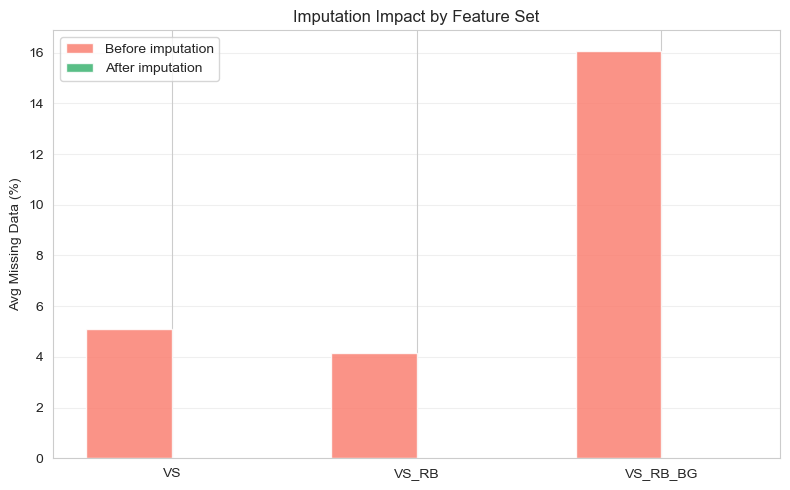


✅ Preprocessing pipeline complete.
   Processed datasets: D:\PyCharmProjects\THS_Prediction\processed\time_windows_imputed
   Splits:             D:\PyCharmProjects\THS_Prediction\processed\splits
   Figures:            D:\PyCharmProjects\THS_Prediction\results\figures
   Next step → 03_modeling.ipynb


In [24]:
# Imputation impact chart
stats_list = []
for T in config.TIME_WINDOWS:
    for ds_name in ['VS','VS_RB','VS_RB_BG']:
        orig = stepped_datasets[T][ds_name]
        imp  = imputed_datasets[T][ds_name]
        feat = [c for c in orig.columns if c not in META_COLS]
        miss_before = orig[feat].isnull().mean().mean() * 100
        miss_after  = imp[feat].isnull().mean().mean() * 100
        stats_list.append({'Dataset': ds_name, 'Before': miss_before, 'After': miss_after})

stat_df = pd.DataFrame(stats_list).groupby('Dataset')[['Before','After']].mean()

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(stat_df))
w = 0.35
ax.bar(x - w/2, stat_df['Before'], w, label='Before imputation', color='salmon', alpha=0.85)
ax.bar(x + w/2, stat_df['After'],  w, label='After imputation',  color='mediumseagreen', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(stat_df.index)
ax.set_ylabel('Avg Missing Data (%)'); ax.set_title('Imputation Impact by Feature Set')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'imputation_impact.png')
plt.show()

print("\n✅ Preprocessing pipeline complete.")
print(f"   Processed datasets: {config.IMPUTED_DIR}")
print(f"   Splits:             {config.SPLIT_DIR}")
print(f"   Figures:            {config.FIGURES_DIR}")
print("   Next step → 03_modeling.ipynb")
